In [1]:
#=======================================
#
# Human-in-the-Loop (HITL) Review Pipeline
#
# MLOps Project
#
# Pablo Rodriguez
#
#
#

In [2]:
from pathlib import Path
from datetime import datetime, timezone
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

RANDOM_STATE = 42
MODEL_VERSION = "occupation-autocoder-v2"

# Initial routing targets.
# We'll validate these before using them.
AUTO_ACCEPT_THRESHOLD = 0.80
ESCALATE_THRESHOLD = 0.50

ARTIFACT_DIR = Path("hitl_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

rng = np.random.default_rng(RANDOM_STATE)

In [3]:
examples = {
    "SOFTWARE": [
        "Develops backend software applications",
        "Writes Python code for business systems",
        "Builds APIs and web applications",
        "Tests and maintains software products",
        "Develops cloud based applications",
        "Maintains enterprise application code",
        "Builds internal software tools",
        "Creates web services and APIs",
    ],

    "FINANCE": [
        "Analyzes financial reports and budgets",
        "Prepares company financial statements",
        "Reviews investment performance",
        "Maintains accounting records",
        "Performs financial forecasting",
        "Analyzes company expenses",
        "Prepares accounting reports",
        "Reviews budgets and financial plans",
    ],

    "HEALTHCARE": [
        "Provides medical care to patients",
        "Assists physicians with treatment",
        "Monitors patient medications",
        "Provides nursing care",
        "Supports medical procedures",
        "Works with patients in a clinic",
        "Provides hospital patient care",
        "Assists with clinical treatment",
    ],

    "EDUCATION": [
        "Teaches mathematics to students",
        "Develops classroom lessons",
        "Provides instruction to students",
        "Teaches science at a school",
        "Evaluates student assignments",
        "Creates classroom materials",
        "Provides educational instruction",
        "Teaches elementary school students",
    ],

    "TRADES": [
        "Installs electrical systems",
        "Repairs plumbing systems",
        "Performs construction work",
        "Repairs heating equipment",
        "Installs residential wiring",
        "Maintains building equipment",
        "Repairs mechanical equipment",
        "Performs building maintenance",
    ]
}

In [4]:
prefixes = [
    "",
    "Employee ",
    "Worker ",
    "Professional "
]

suffixes = [
    "",
    " for customers",
    " for the organization",
    " as part of daily work"
]

rows = []

for label, texts in examples.items():

    for text in texts:

        for _ in range(6):

            rows.append({
                "text": (
                    rng.choice(prefixes)
                    + text.lower()
                    + rng.choice(suffixes)
                ),
                "label": label
            })

data = (
    pd.DataFrame(rows)
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

assert not data.isna().any().any()
assert data["label"].nunique() == 5

print("Records:", len(data))
print()
print(data["label"].value_counts())

Records: 240

label
SOFTWARE      48
FINANCE       48
HEALTHCARE    48
EDUCATION     48
TRADES        48
Name: count, dtype: int64


In [5]:
train_data, temp_data = train_test_split(
    data,
    test_size=0.40,
    stratify=data["label"],
    random_state=RANDOM_STATE
)

validation_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    stratify=temp_data["label"],
    random_state=RANDOM_STATE
)

print("Train:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

Train: 144
Validation: 48
Test: 48


In [6]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=2000
)

X_train = vectorizer.fit_transform(
    train_data["text"]
)

X_validation = vectorizer.transform(
    validation_data["text"]
)

X_test = vectorizer.transform(
    test_data["text"]
)

y_train = train_data["label"]
y_validation = validation_data["label"]
y_test = test_data["label"]

In [7]:
model = LogisticRegression(
    max_iter=500,
    random_state=RANDOM_STATE
)

model.fit(
    X_train,
    y_train
)

print(
    "Trained:",
    MODEL_VERSION
)

Trained: occupation-autocoder-v2


In [8]:
validation_predictions = model.predict(
    X_validation
)

validation_probabilities = model.predict_proba(
    X_validation
)

validation_confidence = (
    validation_probabilities.max(axis=1)
)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

print(
    f"Validation accuracy: "
    f"{validation_accuracy:.2%}"
)

Validation accuracy: 100.00%


In [9]:
validation_analysis = (
    validation_data[
        ["text", "label"]
    ]
    .reset_index(drop=True)
)

validation_analysis[
    "prediction"
] = validation_predictions

validation_analysis[
    "confidence"
] = validation_confidence

validation_analysis[
    "correct"
] = (
    validation_analysis["label"]
    ==
    validation_analysis["prediction"]
)

validation_analysis.sort_values(
    "confidence"
).head(10)

,text,label,prediction,confidence,correct
22,Professional performs financial forecasting as...,FINANCE,FINANCE,0.308929,True
17,Employee provides educational instruction for ...,EDUCATION,EDUCATION,0.409889,True
1,Worker evaluates student assignments for the o...,EDUCATION,EDUCATION,0.421681,True
21,evaluates student assignments as part of daily...,EDUCATION,EDUCATION,0.421910,True
14,Professional evaluates student assignments for...,EDUCATION,EDUCATION,0.445470,True
43,Professional provides educational instruction ...,EDUCATION,EDUCATION,0.447492,True
13,Employee maintains enterprise application code...,SOFTWARE,SOFTWARE,0.451663,True
32,writes python code for business systems as par...,SOFTWARE,SOFTWARE,0.477959,True
34,performs financial forecasting,FINANCE,FINANCE,0.479517,True
44,Professional analyzes financial reports and bu...,FINANCE,FINANCE,0.483883,True


In [10]:
threshold_rows = []

for threshold in np.arange(
    0.50,
    0.96,
    0.05
):

    accepted = (
        validation_analysis[
            "confidence"
        ]
        >= threshold
    )

    coverage = accepted.mean()

    if accepted.any():

        accepted_accuracy = (
            validation_analysis.loc[
                accepted,
                "correct"
            ].mean()
        )

    else:
        accepted_accuracy = np.nan

    threshold_rows.append({
        "threshold":
            round(
                float(threshold),
                2
            ),

        "auto_accept_rate":
            float(coverage),

        "auto_accept_accuracy":
            float(accepted_accuracy)
            if not np.isnan(
                accepted_accuracy
            )
            else np.nan
    })

threshold_analysis = pd.DataFrame(
    threshold_rows
)

threshold_analysis

,threshold,auto_accept_rate,auto_accept_accuracy
0,0.50,0.770833,1.0
1,0.55,0.666667,1.0
2,0.60,0.333333,1.0
3,0.65,0.104167,1.0
4,0.70,0.000000,NaN
5,0.75,0.000000,NaN
6,0.80,0.000000,NaN
7,0.85,0.000000,NaN
8,0.90,0.000000,NaN
9,0.95,0.000000,NaN


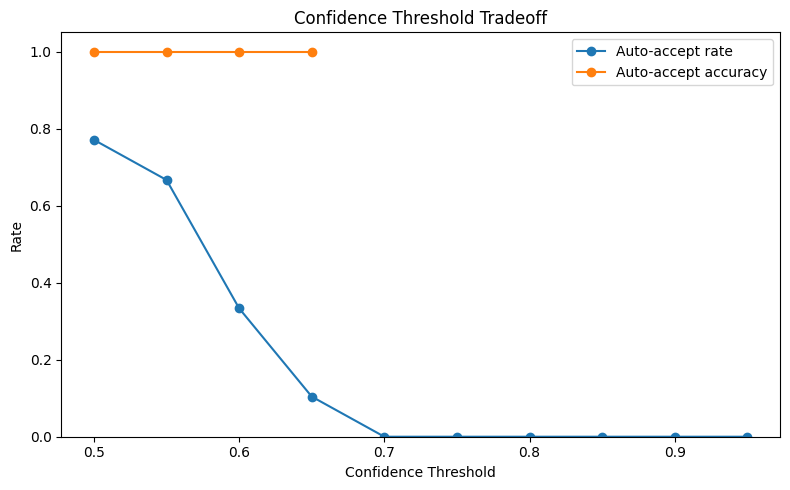

In [11]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis[
        "auto_accept_rate"
    ],
    marker="o",
    label="Auto-accept rate"
)

plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis[
        "auto_accept_accuracy"
    ],
    marker="o",
    label="Auto-accept accuracy"
)

plt.xlabel(
    "Confidence Threshold"
)

plt.ylabel(
    "Rate"
)

plt.title(
    "Confidence Threshold Tradeoff"
)

plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
def route_prediction(confidence):

    if confidence >= AUTO_ACCEPT_THRESHOLD:
        return "AUTO_ACCEPT"

    if confidence >= ESCALATE_THRESHOLD:
        return "HUMAN_REVIEW"

    return "ESCALATE"

In [13]:
assert (
    route_prediction(0.95)
    ==
    "AUTO_ACCEPT"
)

assert (
    route_prediction(0.80)
    ==
    "AUTO_ACCEPT"
)

assert (
    route_prediction(0.65)
    ==
    "HUMAN_REVIEW"
)

assert (
    route_prediction(0.50)
    ==
    "HUMAN_REVIEW"
)

assert (
    route_prediction(0.49)
    ==
    "ESCALATE"
)

print(
    "Routing checks passed."
)

Routing checks passed.


In [14]:
test_predictions = model.predict(
    X_test
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(
    f"Final test accuracy: "
    f"{test_accuracy:.2%}"
)

print()

print(
    classification_report(
        y_test,
        test_predictions
    )
)

Final test accuracy: 100.00%

              precision    recall  f1-score   support

   EDUCATION       1.00      1.00      1.00        10
     FINANCE       1.00      1.00      1.00         9
  HEALTHCARE       1.00      1.00      1.00        10
    SOFTWARE       1.00      1.00      1.00        10
      TRADES       1.00      1.00      1.00         9

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



In [15]:
def predict(text):

    features = vectorizer.transform(
        [text]
    )

    probabilities = model.predict_proba(
        features
    )[0]

    best_index = probabilities.argmax()

    prediction = (
        model.classes_[
            best_index
        ]
    )

    confidence = (
        probabilities[
            best_index
        ]
    )

    return {
        "prediction":
            str(prediction),

        "confidence":
            float(confidence),

        "route":
            route_prediction(
                confidence
            )
    }

In [16]:
predict(
    "Develops Python APIs and software applications"
)

{'prediction': 'SOFTWARE',
 'confidence': 0.7184978555594115,
 'route': 'HUMAN_REVIEW'}

In [17]:
production_data = pd.DataFrame({
    "record_id": [
        "JOB-001",
        "JOB-002",
        "JOB-003",
        "JOB-004",
        "JOB-005",
        "JOB-006",
        "JOB-007",
        "JOB-008",
        "JOB-009",
        "JOB-010"
    ],

    "text": [
        "Develops Python APIs for internal applications",
        "Provides nursing care to hospital patients",
        "Reviews company budgets and financial forecasts",
        "Installs residential electrical wiring",
        "Provides classroom instruction to students",

        "Works with technical systems and business teams",
        "Maintains building systems and equipment",
        "Supports customers with software and account issues",
        "Analyzes records and prepares reports",
        "Works with patients and maintains medical records"
    ]
})

production_data

,record_id,text
0,JOB-001,Develops Python APIs for internal applications
1,JOB-002,Provides nursing care to hospital patients
2,JOB-003,Reviews company budgets and financial forecasts
3,JOB-004,Installs residential electrical wiring
4,JOB-005,Provides classroom instruction to students
5,JOB-006,Works with technical systems and business teams
6,JOB-007,Maintains building systems and equipment
7,JOB-008,Supports customers with software and account i...
8,JOB-009,Analyzes records and prepares reports
9,JOB-010,Works with patients and maintains medical records


In [18]:
production_rows = []

for row in production_data.itertuples(
    index=False
):

    result = predict(
        row.text
    )

    production_rows.append({
        "record_id":
            row.record_id,

        "text":
            row.text,

        "prediction":
            result["prediction"],

        "confidence":
            result["confidence"],

        "route":
            result["route"],

        "model_version":
            MODEL_VERSION
    })

production_results = pd.DataFrame(
    production_rows
)

production_results

,record_id,text,prediction,confidence,route,model_version
0,JOB-001,Develops Python APIs for internal applications,SOFTWARE,0.571473,HUMAN_REVIEW,occupation-autocoder-v2
1,JOB-002,Provides nursing care to hospital patients,HEALTHCARE,0.708380,HUMAN_REVIEW,occupation-autocoder-v2
2,JOB-003,Reviews company budgets and financial forecasts,FINANCE,0.688980,HUMAN_REVIEW,occupation-autocoder-v2
3,JOB-004,Installs residential electrical wiring,TRADES,0.599964,HUMAN_REVIEW,occupation-autocoder-v2
4,JOB-005,Provides classroom instruction to students,EDUCATION,0.745864,HUMAN_REVIEW,occupation-autocoder-v2
5,JOB-006,Works with technical systems and business teams,HEALTHCARE,0.309273,ESCALATE,occupation-autocoder-v2
6,JOB-007,Maintains building systems and equipment,TRADES,0.616357,HUMAN_REVIEW,occupation-autocoder-v2
7,JOB-008,Supports customers with software and account i...,SOFTWARE,0.322889,ESCALATE,occupation-autocoder-v2
8,JOB-009,Analyzes records and prepares reports,FINANCE,0.651219,HUMAN_REVIEW,occupation-autocoder-v2
9,JOB-010,Works with patients and maintains medical records,HEALTHCARE,0.432555,ESCALATE,occupation-autocoder-v2


In [19]:
review_queue = (
    production_results[
        production_results[
            "route"
        ].isin([
            "HUMAN_REVIEW",
            "ESCALATE"
        ])
    ]
    .copy()
    .reset_index(drop=True)
)

review_queue[
    "review_status"
] = "PENDING"

review_queue

,record_id,text,prediction,confidence,route,model_version,review_status
0,JOB-001,Develops Python APIs for internal applications,SOFTWARE,0.571473,HUMAN_REVIEW,occupation-autocoder-v2,PENDING
1,JOB-002,Provides nursing care to hospital patients,HEALTHCARE,0.708380,HUMAN_REVIEW,occupation-autocoder-v2,PENDING
2,JOB-003,Reviews company budgets and financial forecasts,FINANCE,0.688980,HUMAN_REVIEW,occupation-autocoder-v2,PENDING
3,JOB-004,Installs residential electrical wiring,TRADES,0.599964,HUMAN_REVIEW,occupation-autocoder-v2,PENDING
4,JOB-005,Provides classroom instruction to students,EDUCATION,0.745864,HUMAN_REVIEW,occupation-autocoder-v2,PENDING
5,JOB-006,Works with technical systems and business teams,HEALTHCARE,0.309273,ESCALATE,occupation-autocoder-v2,PENDING
6,JOB-007,Maintains building systems and equipment,TRADES,0.616357,HUMAN_REVIEW,occupation-autocoder-v2,PENDING
7,JOB-008,Supports customers with software and account i...,SOFTWARE,0.322889,ESCALATE,occupation-autocoder-v2,PENDING
8,JOB-009,Analyzes records and prepares reports,FINANCE,0.651219,HUMAN_REVIEW,occupation-autocoder-v2,PENDING
9,JOB-010,Works with patients and maintains medical records,HEALTHCARE,0.432555,ESCALATE,occupation-autocoder-v2,PENDING


In [20]:
priority = {
    "ESCALATE": 0,
    "HUMAN_REVIEW": 1
}

review_queue[
    "priority"
] = review_queue[
    "route"
].map(priority)

review_queue = (
    review_queue
    .sort_values(
        [
            "priority",
            "confidence"
        ]
    )
    .reset_index(drop=True)
)

review_queue

,record_id,text,prediction,confidence,route,model_version,review_status,priority
0,JOB-006,Works with technical systems and business teams,HEALTHCARE,0.309273,ESCALATE,occupation-autocoder-v2,PENDING,0
1,JOB-008,Supports customers with software and account i...,SOFTWARE,0.322889,ESCALATE,occupation-autocoder-v2,PENDING,0
2,JOB-010,Works with patients and maintains medical records,HEALTHCARE,0.432555,ESCALATE,occupation-autocoder-v2,PENDING,0
3,JOB-001,Develops Python APIs for internal applications,SOFTWARE,0.571473,HUMAN_REVIEW,occupation-autocoder-v2,PENDING,1
4,JOB-004,Installs residential electrical wiring,TRADES,0.599964,HUMAN_REVIEW,occupation-autocoder-v2,PENDING,1
5,JOB-007,Maintains building systems and equipment,TRADES,0.616357,HUMAN_REVIEW,occupation-autocoder-v2,PENDING,1
6,JOB-009,Analyzes records and prepares reports,FINANCE,0.651219,HUMAN_REVIEW,occupation-autocoder-v2,PENDING,1
7,JOB-003,Reviews company budgets and financial forecasts,FINANCE,0.688980,HUMAN_REVIEW,occupation-autocoder-v2,PENDING,1
8,JOB-002,Provides nursing care to hospital patients,HEALTHCARE,0.708380,HUMAN_REVIEW,occupation-autocoder-v2,PENDING,1
9,JOB-005,Provides classroom instruction to students,EDUCATION,0.745864,HUMAN_REVIEW,occupation-autocoder-v2,PENDING,1


In [21]:
routing_summary = (
    production_results[
        "route"
    ]
    .value_counts()
)

routing_summary

,count
route,
HUMAN_REVIEW,7
ESCALATE,3


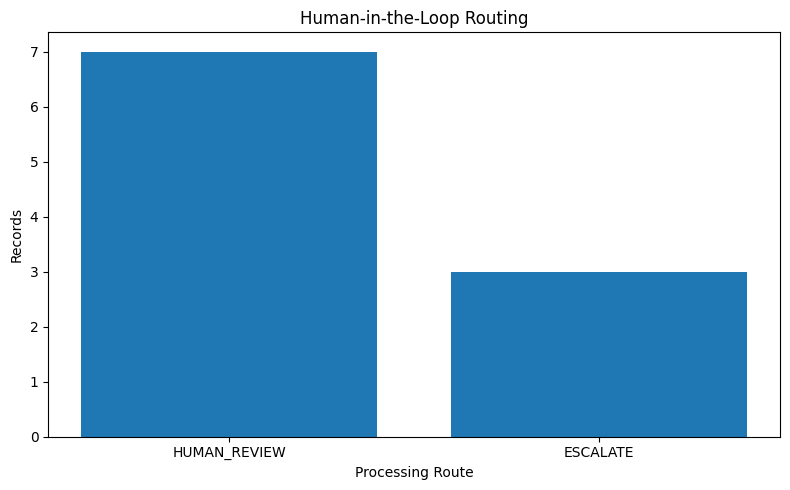

In [22]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    routing_summary.index,
    routing_summary.values
)

plt.xlabel(
    "Processing Route"
)

plt.ylabel(
    "Records"
)

plt.title(
    "Human-in-the-Loop Routing"
)

plt.tight_layout()
plt.show()

In [23]:
VALID_LABELS = set(
    model.classes_
)


def review_record(
    record_id,
    reviewer_label,
    reviewer_id="reviewer-001"
):

    if reviewer_label not in VALID_LABELS:
        raise ValueError(
            f"Invalid label: "
            f"{reviewer_label}"
        )

    matches = review_queue[
        review_queue[
            "record_id"
        ]
        ==
        record_id
    ]

    if matches.empty:
        raise ValueError(
            f"{record_id} is not "
            "in the review queue."
        )

    row = matches.iloc[0]

    return {
        "record_id":
            record_id,

        "text":
            row["text"],

        "original_route":
            row["route"],

        "model_prediction":
            row["prediction"],

        "model_confidence":
            float(
                row["confidence"]
            ),

        "reviewer_label":
            reviewer_label,

        "reviewer_id":
            reviewer_id,

        "corrected":
            bool(
                reviewer_label
                !=
                row["prediction"]
            ),

        "reviewed_at":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "model_version":
            MODEL_VERSION
    }

In [24]:
human_labels = {
    "JOB-006": "SOFTWARE",
    "JOB-007": "TRADES",
    "JOB-008": "SOFTWARE",
    "JOB-009": "FINANCE",
    "JOB-010": "HEALTHCARE"
}

In [25]:
reviews = []

for record_id in review_queue[
    "record_id"
]:

    if record_id in human_labels:

        reviews.append(
            review_record(
                record_id,
                human_labels[
                    record_id
                ]
            )
        )

review_log = pd.DataFrame(
    reviews
)

review_log

,record_id,text,original_route,model_prediction,model_confidence,reviewer_label,reviewer_id,corrected,reviewed_at,model_version
0,JOB-006,Works with technical systems and business teams,ESCALATE,HEALTHCARE,0.309273,SOFTWARE,reviewer-001,True,2026-09-28T19:24:12.107430+00:00,occupation-autocoder-v2
1,JOB-008,Supports customers with software and account i...,ESCALATE,SOFTWARE,0.322889,SOFTWARE,reviewer-001,False,2026-09-28T19:24:12.108270+00:00,occupation-autocoder-v2
2,JOB-010,Works with patients and maintains medical records,ESCALATE,HEALTHCARE,0.432555,HEALTHCARE,reviewer-001,False,2026-09-28T19:24:12.110947+00:00,occupation-autocoder-v2
3,JOB-007,Maintains building systems and equipment,HUMAN_REVIEW,TRADES,0.616357,TRADES,reviewer-001,False,2026-09-28T19:24:12.111712+00:00,occupation-autocoder-v2
4,JOB-009,Analyzes records and prepares reports,HUMAN_REVIEW,FINANCE,0.651219,FINANCE,reviewer-001,False,2026-09-28T19:24:12.114353+00:00,occupation-autocoder-v2


In [26]:
final_results = (
    production_results.copy()
)

needs_review = (
    final_results[
        "route"
    ].isin([
        "HUMAN_REVIEW",
        "ESCALATE"
    ])
)

final_results[
    "final_label"
] = final_results[
    "prediction"
]

final_results[
    "decision_source"
] = "MODEL"

final_results.loc[
    needs_review,
    "final_label"
] = None

final_results.loc[
    needs_review,
    "decision_source"
] = "PENDING_REVIEW"


for review in review_log.itertuples(
    index=False
):

    mask = (
        final_results[
            "record_id"
        ]
        ==
        review.record_id
    )

    final_results.loc[
        mask,
        "final_label"
    ] = review.reviewer_label

    final_results.loc[
        mask,
        "decision_source"
    ] = "HUMAN"


final_results

,record_id,text,prediction,confidence,route,model_version,final_label,decision_source
0,JOB-001,Develops Python APIs for internal applications,SOFTWARE,0.571473,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
1,JOB-002,Provides nursing care to hospital patients,HEALTHCARE,0.708380,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
2,JOB-003,Reviews company budgets and financial forecasts,FINANCE,0.688980,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
3,JOB-004,Installs residential electrical wiring,TRADES,0.599964,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
4,JOB-005,Provides classroom instruction to students,EDUCATION,0.745864,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
5,JOB-006,Works with technical systems and business teams,HEALTHCARE,0.309273,ESCALATE,occupation-autocoder-v2,SOFTWARE,HUMAN
6,JOB-007,Maintains building systems and equipment,TRADES,0.616357,HUMAN_REVIEW,occupation-autocoder-v2,TRADES,HUMAN
7,JOB-008,Supports customers with software and account i...,SOFTWARE,0.322889,ESCALATE,occupation-autocoder-v2,SOFTWARE,HUMAN
8,JOB-009,Analyzes records and prepares reports,FINANCE,0.651219,HUMAN_REVIEW,occupation-autocoder-v2,FINANCE,HUMAN
9,JOB-010,Works with patients and maintains medical records,HEALTHCARE,0.432555,ESCALATE,occupation-autocoder-v2,HEALTHCARE,HUMAN


In [27]:
unresolved = (
    final_results[
        final_results[
            "decision_source"
        ]
        ==
        "PENDING_REVIEW"
    ]
)

print(
    "Pending reviews:",
    len(unresolved)
)

unresolved

Pending reviews: 5


,record_id,text,prediction,confidence,route,model_version,final_label,decision_source
0,JOB-001,Develops Python APIs for internal applications,SOFTWARE,0.571473,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
1,JOB-002,Provides nursing care to hospital patients,HEALTHCARE,0.708380,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
2,JOB-003,Reviews company budgets and financial forecasts,FINANCE,0.688980,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
3,JOB-004,Installs residential electrical wiring,TRADES,0.599964,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW
4,JOB-005,Provides classroom instruction to students,EDUCATION,0.745864,HUMAN_REVIEW,occupation-autocoder-v2,None,PENDING_REVIEW


In [28]:
total_records = len(
    production_results
)

auto_accepted = int(
    (
        production_results[
            "route"
        ]
        ==
        "AUTO_ACCEPT"
    ).sum()
)

review_required = int(
    production_results[
        "route"
    ].isin([
        "HUMAN_REVIEW",
        "ESCALATE"
    ]).sum()
)

escalated = int(
    (
        production_results[
            "route"
        ]
        ==
        "ESCALATE"
    ).sum()
)

reviews_completed = len(
    review_log
)

auto_accept_rate = (
    auto_accepted
    /
    total_records
)

review_rate = (
    review_required
    /
    total_records
)

escalation_rate = (
    escalated
    /
    total_records
)

review_completion_rate = (
    reviews_completed
    /
    review_required
    if review_required
    else 1.0
)

correction_rate = (
    review_log[
        "corrected"
    ].mean()
    if len(review_log)
    else 0.0
)

print(
    "Auto-accept rate:",
    f"{auto_accept_rate:.2%}"
)

print(
    "Review rate:",
    f"{review_rate:.2%}"
)

print(
    "Escalation rate:",
    f"{escalation_rate:.2%}"
)

print(
    "Review completion:",
    f"{review_completion_rate:.2%}"
)

print(
    "Reviewer correction rate:",
    f"{correction_rate:.2%}"
)

Auto-accept rate: 0.00%
Review rate: 100.00%
Escalation rate: 30.00%
Review completion: 50.00%
Reviewer correction rate: 20.00%


In [29]:
feedback_data = (
    review_log[
        [
            "record_id",
            "text",
            "reviewer_label",
            "model_prediction",
            "model_confidence",
            "corrected",
            "model_version"
        ]
    ]
    .rename(
        columns={
            "reviewer_label":
                "human_label"
        }
    )
    .copy()
)

feedback_data

,record_id,text,human_label,model_prediction,model_confidence,corrected,model_version
0,JOB-006,Works with technical systems and business teams,SOFTWARE,HEALTHCARE,0.309273,True,occupation-autocoder-v2
1,JOB-008,Supports customers with software and account i...,SOFTWARE,SOFTWARE,0.322889,False,occupation-autocoder-v2
2,JOB-010,Works with patients and maintains medical records,HEALTHCARE,HEALTHCARE,0.432555,False,occupation-autocoder-v2
3,JOB-007,Maintains building systems and equipment,TRADES,TRADES,0.616357,False,occupation-autocoder-v2
4,JOB-009,Analyzes records and prepares reports,FINANCE,FINANCE,0.651219,False,occupation-autocoder-v2


In [30]:
correction_data = (
    feedback_data[
        feedback_data[
            "corrected"
        ]
    ]
    .copy()
)

print(
    "Human corrections:",
    len(correction_data)
)

correction_data

Human corrections: 1


,record_id,text,human_label,model_prediction,model_confidence,corrected,model_version
0,JOB-006,Works with technical systems and business teams,SOFTWARE,HEALTHCARE,0.309273,True,occupation-autocoder-v2


In [31]:
evaluation_candidates = (
    feedback_data[
        [
            "text",
            "human_label"
        ]
    ]
    .rename(
        columns={
            "human_label":
                "expected_label"
        }
    )
    .drop_duplicates()
    .reset_index(drop=True)
)

evaluation_candidates

,text,expected_label
0,Works with technical systems and business teams,SOFTWARE
1,Supports customers with software and account i...,SOFTWARE
2,Works with patients and maintains medical records,HEALTHCARE
3,Maintains building systems and equipment,TRADES
4,Analyzes records and prepares reports,FINANCE


In [32]:
MODEL_PATH = (
    ARTIFACT_DIR
    / "autocoder.joblib"
)

joblib.dump(
    {
        "model":
            model,

        "vectorizer":
            vectorizer,

        "model_version":
            MODEL_VERSION,

        "auto_accept_threshold":
            AUTO_ACCEPT_THRESHOLD,

        "escalate_threshold":
            ESCALATE_THRESHOLD
    },
    MODEL_PATH
)

print(
    "Saved:",
    MODEL_PATH
)

Saved: hitl_artifacts/autocoder.joblib


In [33]:
QUEUE_PATH = (
    ARTIFACT_DIR
    / "review_queue.csv"
)

REVIEW_LOG_PATH = (
    ARTIFACT_DIR
    / "review_log.csv"
)

FINAL_RESULTS_PATH = (
    ARTIFACT_DIR
    / "final_results.csv"
)

FEEDBACK_PATH = (
    ARTIFACT_DIR
    / "feedback_data.csv"
)

EVAL_CANDIDATES_PATH = (
    ARTIFACT_DIR
    / "evaluation_candidates.csv"
)


review_queue.to_csv(
    QUEUE_PATH,
    index=False
)

review_log.to_csv(
    REVIEW_LOG_PATH,
    index=False
)

final_results.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)

feedback_data.to_csv(
    FEEDBACK_PATH,
    index=False
)

evaluation_candidates.to_csv(
    EVAL_CANDIDATES_PATH,
    index=False
)

print(
    "Review artifacts saved."
)

Review artifacts saved.


In [34]:
REPORT_PATH = (
    ARTIFACT_DIR
    / "hitl_report.json"
)

report = {
    "timestamp":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "model_version":
        MODEL_VERSION,

    "thresholds": {
        "auto_accept":
            AUTO_ACCEPT_THRESHOLD,

        "escalate":
            ESCALATE_THRESHOLD
    },

    "model": {
        "validation_accuracy":
            float(
                validation_accuracy
            ),

        "test_accuracy":
            float(
                test_accuracy
            )
    },

    "production": {
        "total_records":
            int(
                total_records
            ),

        "auto_accepted":
            auto_accepted,

        "review_required":
            review_required,

        "escalated":
            escalated,

        "reviews_completed":
            int(
                reviews_completed
            )
    },

    "metrics": {
        "auto_accept_rate":
            float(
                auto_accept_rate
            ),

        "review_rate":
            float(
                review_rate
            ),

        "escalation_rate":
            float(
                escalation_rate
            ),

        "review_completion_rate":
            float(
                review_completion_rate
            ),

        "correction_rate":
            float(
                correction_rate
            )
    }
}

with open(
    REPORT_PATH,
    "w"
) as file:

    json.dump(
        report,
        file,
        indent=4
    )

report

{'timestamp': '2026-09-28T19:24:12.840571+00:00',
 'model_version': 'occupation-autocoder-v2',
 'thresholds': {'auto_accept': 0.8, 'escalate': 0.5},
 'model': {'validation_accuracy': 1.0, 'test_accuracy': 1.0},
 'production': {'total_records': 10,
  'auto_accepted': 0,
  'review_required': 10,
  'escalated': 3,
  'reviews_completed': 5},
 'metrics': {'auto_accept_rate': 0.0,
  'review_rate': 1.0,
  'escalation_rate': 0.3,
  'review_completion_rate': 0.5,
  'correction_rate': 0.2}}

In [35]:
loaded = joblib.load(
    MODEL_PATH
)

loaded_model = loaded[
    "model"
]

loaded_vectorizer = loaded[
    "vectorizer"
]

print(
    "Loaded:",
    loaded[
        "model_version"
    ]
)

Loaded: occupation-autocoder-v2


In [36]:
def smoke_test():

    # Dataset
    assert (
        data[
            "label"
        ].nunique()
        ==
        5
    )

    assert (
        len(train_data)
        +
        len(validation_data)
        +
        len(test_data)
        ==
        len(data)
    )

    # Model
    assert (
        0
        <= validation_accuracy
        <= 1
    )

    assert (
        0
        <= test_accuracy
        <= 1
    )

    # Thresholds
    assert (
        0
        <= ESCALATE_THRESHOLD
        <
        AUTO_ACCEPT_THRESHOLD
        <= 1
    )

    # Routing
    assert (
        route_prediction(
            AUTO_ACCEPT_THRESHOLD
        )
        ==
        "AUTO_ACCEPT"
    )

    assert (
        route_prediction(
            ESCALATE_THRESHOLD
        )
        ==
        "HUMAN_REVIEW"
    )

    assert (
        route_prediction(
            ESCALATE_THRESHOLD
            - 0.01
        )
        ==
        "ESCALATE"
    )

    valid_routes = {
        "AUTO_ACCEPT",
        "HUMAN_REVIEW",
        "ESCALATE"
    }

    assert set(
        production_results[
            "route"
        ]
    ).issubset(
        valid_routes
    )

    # Safety:
    # pending reviews cannot have final labels.
    pending = (
        final_results[
            "decision_source"
        ]
        ==
        "PENDING_REVIEW"
    )

    assert (
        final_results.loc[
            pending,
            "final_label"
        ]
        .isna()
        .all()
    )

    # Human-reviewed records must
    # use the reviewer decision.
    for review in review_log.itertuples(
        index=False
    ):

        final_row = (
            final_results[
                final_results[
                    "record_id"
                ]
                ==
                review.record_id
            ]
            .iloc[0]
        )

        assert (
            final_row[
                "final_label"
            ]
            ==
            review.reviewer_label
        )

        assert (
            final_row[
                "decision_source"
            ]
            ==
            "HUMAN"
        )

    # Artifacts
    paths = [
        MODEL_PATH,
        QUEUE_PATH,
        REVIEW_LOG_PATH,
        FINAL_RESULTS_PATH,
        FEEDBACK_PATH,
        EVAL_CANDIDATES_PATH,
        REPORT_PATH
    ]

    assert all(
        path.exists()
        for path in paths
    )

    # Reload check
    sample = (
        "Develops Python software"
    )

    original_prediction = (
        model.predict(
            vectorizer.transform(
                [sample]
            )
        )[0]
    )

    loaded_prediction = (
        loaded_model.predict(
            loaded_vectorizer.transform(
                [sample]
            )
        )[0]
    )

    assert (
        original_prediction
        ==
        loaded_prediction
    )

    print(
        "✅ Human-in-the-loop pipeline passed."
    )


smoke_test()

✅ Human-in-the-loop pipeline passed.
